#### HyperParameters and Parameters

##### Introduction & 'Parameters'

Extracting a Logistic Regression Parameters

In [1]:
X_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 
        'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
        'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 
        'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']



In [6]:
import pandas as pd 
from sklearn.model_selection import train_test_split

data = pd.read_csv("./datasets/credit-card-full.csv")
X = data.drop("default payment next month", axis=1)
y = data["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_sacled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

original_variables = list(X.columns)


coefficient_df = pd.DataFrame({
        "Column Name": original_variables,
        "Model Coefficients": log_reg.coef_[0]
    })

display(coefficient_df.sort_values(by="Model Coefficients", axis=0, ascending=False)[0:3])


,Column Name,Model Coefficients
6,PAY_0,0.660455
8,PAY_3,0.096683
7,PAY_2,0.093528


Extracting a Random Forest Parameter

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
import matplotlib.pyplot as plt 
plt.imshow()

TypeError: imshow() missing 1 required positional argument: 'X'

In [ ]:
import sys
!{sys.executable} -m pip install pydotplus

  Using cached pydotplus-2.0.2-py3-none-any.whl



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

# select a particular tree from the forest 
chosen_tree = rf_clf.estimators_[7]

# Export the chosen tree as DOT data
dot_data = export_graphviz(
    chosen_tree,
    out_file=None,
    feature_names=X_train.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True
)

# Convert DOT data to PNG
graph = pydotplus.graph_from_dot_data(dot_data)

tree_viz_image = graph.create_png()

# Display the tree
display(Image(tree_viz_image))

InvocationException: GraphViz's executables not found

##### Introducing Hyperparameters

Exploring Random Forest HyperParameters

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf_clf_old = RandomForestClassifier(max_depth=5)
rf_clf_old.fit(X_train, y_train)
rf_old_predictions = rf_clf_old.predict(X_test)
print(accuracy_score(y_test, rf_old_predictions))
print(confusion_matrix(y_test, rf_old_predictions))

rf_clf_new = RandomForestClassifier(max_depth=500)
rf_clf_new.fit(X_train, y_train)
rf_new_predictions = rf_clf_new.predict(X_test)
print(accuracy_score(y_test, rf_new_predictions))
print(confusion_matrix(y_test, rf_new_predictions))

0.8115
[[4478  195]
 [ 936  391]]
0.8135
[[4396  277]
 [ 842  485]]


HyperParameters on KNN

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Build a knn estimator for each value of n_neighbours
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_10 = KNeighborsClassifier(n_neighbors=10)
knn_20 = KNeighborsClassifier(n_neighbors=20)

# Fit each to the training data & produce predictions
knn_5_predictions = knn_5.fit(X_train, y_train).predict(X_test)
knn_10_predictions = knn_10.fit(X_train, y_train).predict(X_test)
knn_20_predictions = knn_20.fit(X_train, y_train).predict(X_test)

# Get an accuracy score for each of the models
knn_5_accuracy = accuracy_score(y_test, knn_5_predictions)
knn_10_accuracy = accuracy_score(y_test, knn_10_predictions)
knn_20_accuracy = accuracy_score(y_test, knn_20_predictions)
print("The accuracy of 5, 10, 20 neighbours was {}, {}, {}".format(knn_5_accuracy, knn_10_accuracy, knn_20_accuracy))

The accuracy of 5, 10, 20 neighbours was 0.7521666666666667, 0.775, 0.7758333333333334


##### Setting and Analysing HyperParameter Values

Automating Hyperparameter Choice

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
results_list = []

for learning_rate in learning_rates:
    model = GradientBoostingClassifier(learning_rate=learning_rate)
    model.fit(X_train, y_train)
    results_list.append([learning_rate, accuracy_score(y_test, model.predict(X_test))])

results_df = pd.DataFrame(results_list, columns=["Learning Rate", "Accuracy Score"])

In [14]:
results_df

,Learning Rate,Accuracy Score
0,0.001,0.778833
1,0.010,0.818833
2,0.050,0.819167
3,0.100,0.819333
4,0.200,0.817833
5,0.500,0.805667


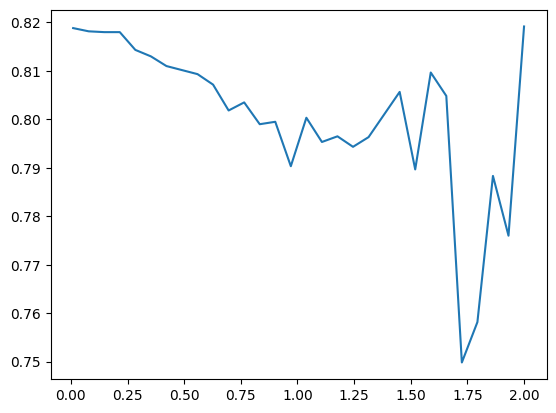

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt 

learn_rates = np.linspace(0.01, 2, num=30)
accuracies = []

for learn_rate in learn_rates:
    model = GradientBoostingClassifier(learning_rate=learn_rate)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(learn_rates, accuracies)
plt.show()